In [24]:
import warnings
warnings.filterwarnings("ignore")

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("dataset/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [28]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


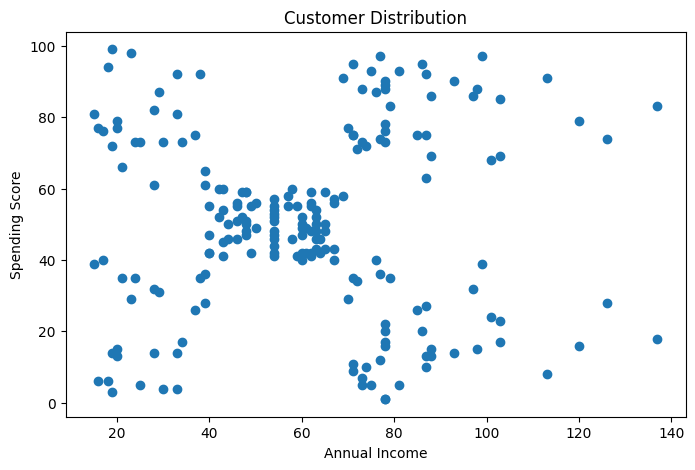

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")

plt.show()

In [30]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [31]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [32]:
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings("ignore")

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

In [33]:
len(wcss)

10

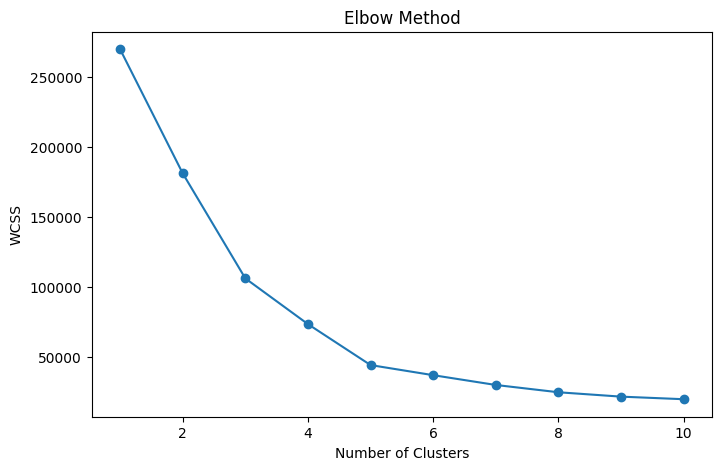

In [34]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [35]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


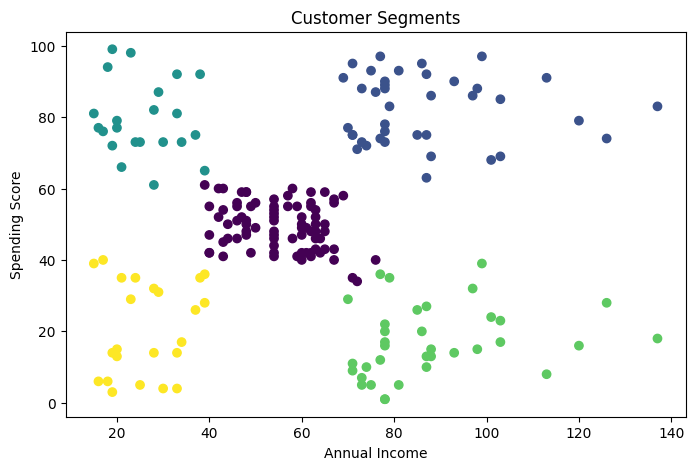

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")

plt.show()

In [37]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [38]:
import joblib

joblib.dump(kmeans, "models/kmeans_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


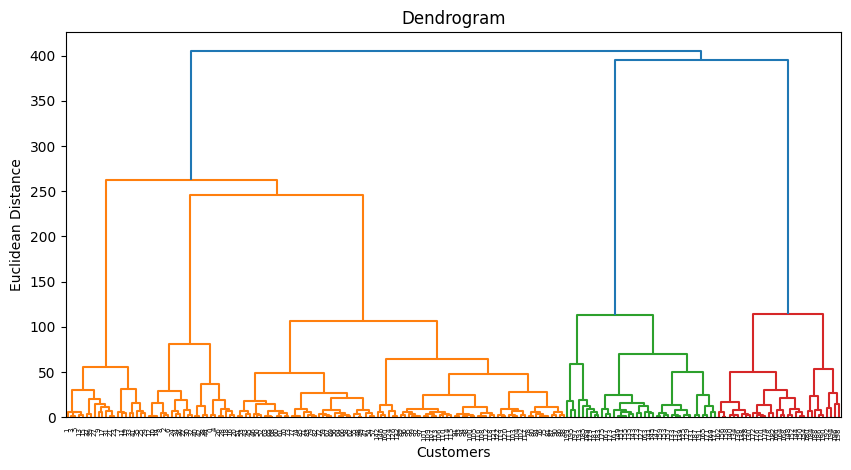

In [39]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

dendrogram = sch.dendrogram(
    sch.linkage(X, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [40]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5
)

df['HC_Cluster'] = hc.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,HC_Cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,4,4


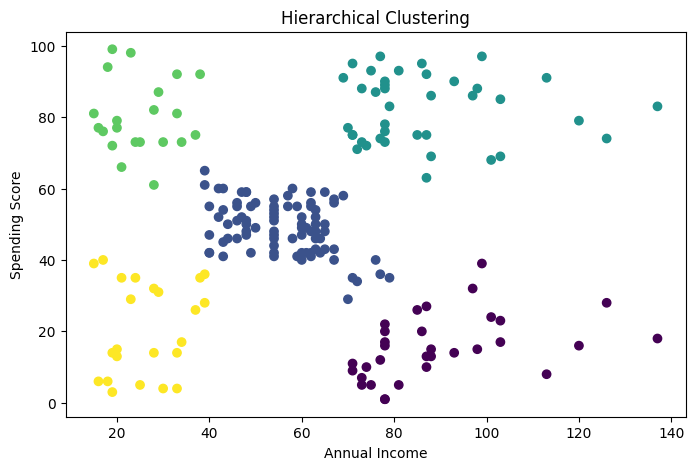

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['HC_Cluster']
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Hierarchical Clustering")

plt.show()

In [42]:
df.groupby('HC_Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster
HC_Cluster,,,,,
0,166.250000,41.000000,89.406250,15.593750,3.000000
1,87.894118,42.482353,55.811765,49.129412,0.129412
2,162.000000,32.692308,86.538462,82.128205,1.000000
3,22.000000,25.333333,25.095238,80.047619,2.000000
4,23.000000,45.217391,26.304348,20.913043,4.000000


In [43]:
comparison = {
    "Feature": [
        "Speed",
        "Dendrogram",
        "Large Dataset Handling",
        "Customer Segmentation"
    ],
    "K-Means": [
        "Fast",
        "No",
        "Good",
        "Good"
    ],
    "Hierarchical": [
        "Slower",
        "Yes",
        "Moderate",
        "Good"
    ]
}

import pandas as pd

pd.DataFrame(comparison)

,Feature,K-Means,Hierarchical
0,Speed,Fast,Slower
1,Dendrogram,No,Yes
2,Large Dataset Handling,Good,Moderate
3,Customer Segmentation,Good,Good
